In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK2_REPO_ROOT = (
    REPO_ROOT / "task2"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

CHECKPOINT_DIRECTORY = (
    TASK2_WORK_ROOT / "checkpoints"
)

CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import yaml

import matplotlib.pyplot as plt

import pandas as pd

import torch

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_loaders import (
    build_pacs_datasets,
    build_pacs_loaders,
)

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task2.train import (
    train_task2_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK2_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK2_REPO_ROOT
    / "configs/dan.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    dan_config = yaml.safe_load(
        config_file
    )

print("DAN configuration:")
print(
    yaml.safe_dump(
        dan_config,
        sort_keys=False,
    )
)

print(
    "Target labels allowed:",
    base_config["selection"][
        "use_target_labels"
    ],
)

print(
    "Gradient clip norm:",
    base_config["optimization"][
        "gradient_clip_norm"
    ],
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
DAN configuration:
method:
  name: dan
  uses_unlabeled_target: true
  classification_loss_weight: 1.0
  mmd_weight: 1.0
  kernel: multi_rbf
  bandwidth_multipliers:
  - 0.5
  - 1.0
  - 2.0
  bandwidth_statistic: median_pairwise_squared_distance
checkpoint:
  filename: dan_best.pt

Target labels allowed: False
Gradient clip norm: 1.0


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

print(
    "PACS images:",
    len(pacs_dataset),
)

print(
    "Source domains:",
    pacs_protocol["source_domains"],
)

print(
    "Unlabeled target:",
    pacs_protocol["target_domain"],
)

PACS images: 9991
Source domains: ['photo', 'art_painting', 'cartoon']
Unlabeled target: sketch


In [6]:
pacs_datasets = build_pacs_datasets(
    dataset=pacs_dataset,
    protocol=pacs_protocol,
)

target_sample = (
    pacs_datasets[
        "target_adaptation"
    ][0]
)

print(
    "Source training domains:",
    list(
        pacs_datasets[
            "source_train"
        ].keys()
    ),
)

print(
    "Target samples:",
    len(
        pacs_datasets[
            "target_adaptation"
        ]
    ),
)

print(
    "Target label exposed:",
    "label" in target_sample,
)

Source training domains: ['photo', 'art_painting', 'cartoon']
Target samples: 3929
Target label exposed: False


In [7]:
MMD_WEIGHTS_TO_TRAIN = [
    0.1,
    10.0,
]

WEIGHT_TAGS = {
    0.1: "0p1",
    10.0: "10",
}

BANDWIDTH_MULTIPLIERS = (
    dan_config["method"][
        "bandwidth_multipliers"
    ]
)

print(
    "MMD weights to train:",
    MMD_WEIGHTS_TO_TRAIN,
)

print(
    "Bandwidth multipliers:",
    BANDWIDTH_MULTIPLIERS,
)

MMD weights to train: [0.1, 10.0]
Bandwidth multipliers: [0.5, 1.0, 2.0]


In [8]:
def run_dan_controlled_experiment(
    mmd_weight,
):
    set_seed(SEED)

    experiment_tag = (
        WEIGHT_TAGS[mmd_weight]
    )

    experiment_loaders = (
        build_pacs_loaders(
            datasets=pacs_datasets,
            source_batch_size=8,
            target_batch_size=24,
            evaluation_batch_size=64,
            number_of_workers=2,
            seed=SEED,
        )
    )

    experiment_model = (
        PACSClassifier(
            number_of_classes=7
        ).to(DEVICE)
    )

    experiment_optimizer = (
        torch.optim.AdamW(
            experiment_model.parameters(),
            lr=(
                base_config[
                    "optimization"
                ]["learning_rate"]
            ),
            weight_decay=(
                base_config[
                    "optimization"
                ]["weight_decay"]
            ),
        )
    )

    checkpoint_path = (
        CHECKPOINT_DIRECTORY
        / (
            "dan_lambda_"
            f"{experiment_tag}_best.pt"
        )
    )

    experiment_selector = (
        SourceValidationSelector(
            checkpoint_path=(
                checkpoint_path
            ),
            patience=(
                base_config[
                    "optimization"
                ][
                    "early_stopping_patience"
                ]
            ),
        )
    )

    print()
    print("=" * 70)
    print(
        "Training DAN with "
        f"MMD weight = {mmd_weight}"
    )
    print("=" * 70)

    training_result = (
        train_task2_method(
            method_name="dan",
            model=experiment_model,
            loaders=experiment_loaders,
            optimizer=(
                experiment_optimizer
            ),
            selector=(
                experiment_selector
            ),
            device=DEVICE,
            maximum_epochs=(
                base_config[
                    "optimization"
                ]["maximum_epochs"]
            ),
            method_parameters={
                "mmd_weight": float(
                    mmd_weight
                ),
                "bandwidth_multipliers": (
                    BANDWIDTH_MULTIPLIERS
                ),
            },
            number_of_classes=7,
            gradient_clip_norm=1.0,
        )
    )

    selected_model = (
        training_result["model"]
    )

    history = (
        training_result["history"]
    )

    selected_checkpoint = (
        training_result[
            "selected_checkpoint"
        ]
    )

    validation_results = (
        evaluate_source_domains(
            model=selected_model,
            validation_loaders=(
                experiment_loaders[
                    "source_validation"
                ]
            ),
            device=DEVICE,
            number_of_classes=7,
        )
    )

    history_path = (
        TASK2_REPO_ROOT
        / "results"
        / (
            "dan_lambda_"
            f"{experiment_tag}_"
            "training_history.csv"
        )
    )

    history.to_csv(
        history_path,
        index=False,
    )

    validation_rows = []

    for domain_name, metrics in (
        validation_results[
            "domains"
        ].items()
    ):
        validation_rows.append(
            {
                "mmd_weight": float(
                    mmd_weight
                ),
                "domain": domain_name,
                "accuracy": (
                    metrics["accuracy"]
                ),
                "macro_f1": (
                    metrics["macro_f1"]
                ),
                "loss": metrics["loss"],
                "number_of_samples": (
                    metrics[
                        "number_of_samples"
                    ]
                ),
            }
        )

    validation_table = pd.DataFrame(
        validation_rows
    )

    validation_path = (
        TASK2_REPO_ROOT
        / "results"
        / (
            "dan_lambda_"
            f"{experiment_tag}_"
            "source_validation.csv"
        )
    )

    validation_table.to_csv(
        validation_path,
        index=False,
    )

    print()
    print(
        "Selected epoch:",
        selected_checkpoint["epoch"],
    )

    print(
        "Selected mean source macro-F1:",
        selected_checkpoint[
            "selection_score"
        ],
    )

    return {
        "mmd_weight": float(
            mmd_weight
        ),
        "tag": experiment_tag,
        "history": history,
        "selected_checkpoint": (
            selected_checkpoint
        ),
        "validation_results": (
            validation_results
        ),
        "validation_table": (
            validation_table
        ),
        "checkpoint_path": (
            checkpoint_path
        ),
    }

In [9]:
controlled_results = {}

for mmd_weight in (
    MMD_WEIGHTS_TO_TRAIN
):
    controlled_results[
        mmd_weight
    ] = (
        run_dan_controlled_experiment(
            mmd_weight=mmd_weight
        )
    )

print()
print(
    "Completed weights:",
    list(controlled_results.keys()),
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]



Training DAN with MMD weight = 0.1


dan epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=0.4978, mean validation macro-F1=0.8474, best=0.8474


...

Epoch 4: train loss=4.0384, mean validation macro-F1=0.0507, best=0.0507


dan epoch 5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 5: train loss=4.2571, mean validation macro-F1=0.0507, best=0.0507


dan epoch 6:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 6: train loss=4.7530, mean validation macro-F1=0.0507, best=0.0507
Early stopping triggered.

Selected epoch: 1
Selected mean source macro-F1: 0.05066996495567924

Completed weights: [0.1, 10.0]


In [10]:
lambda_one_history_path = (
    TASK2_REPO_ROOT
    / "results/dan_training_history.csv"
)

lambda_one_validation_path = (
    TASK2_REPO_ROOT
    / "results/dan_source_validation.csv"
)

lambda_one_history = pd.read_csv(
    lambda_one_history_path
)

lambda_one_validation = pd.read_csv(
    lambda_one_validation_path
)

lambda_one_validation[
    "mmd_weight"
] = 1.0

lambda_one_best_index = (
    lambda_one_history[
        "mean_source_validation_macro_f1"
    ].idxmax()
)

lambda_one_selected_row = (
    lambda_one_history.loc[
        lambda_one_best_index
    ]
)

controlled_validation_table = (
    pd.concat(
        [
            controlled_results[
                0.1
            ]["validation_table"],
            lambda_one_validation,
            controlled_results[
                10.0
            ]["validation_table"],
        ],
        ignore_index=True,
    )
)

controlled_validation_table = (
    controlled_validation_table[
        [
            "mmd_weight",
            "domain",
            "accuracy",
            "macro_f1",
            "loss",
            "number_of_samples",
        ]
    ]
)

summary_rows = []

for mmd_weight in [
    0.1,
    1.0,
    10.0,
]:
    weight_results = (
        controlled_validation_table[
            controlled_validation_table[
                "mmd_weight"
            ]
            == mmd_weight
        ]
    )

    if mmd_weight == 1.0:
        selected_epoch = int(
            lambda_one_selected_row[
                "epoch"
            ]
        )
    else:
        selected_epoch = int(
            controlled_results[
                mmd_weight
            ][
                "selected_checkpoint"
            ]["epoch"]
        )

    summary_rows.append(
        {
            "mmd_weight": mmd_weight,
            "selected_epoch": (
                selected_epoch
            ),
            "mean_source_accuracy": (
                weight_results[
                    "accuracy"
                ].mean()
            ),
            "mean_source_macro_f1": (
                weight_results[
                    "macro_f1"
                ].mean()
            ),
            "worst_source_accuracy": (
                weight_results[
                    "accuracy"
                ].min()
            ),
            "worst_source_macro_f1": (
                weight_results[
                    "macro_f1"
                ].min()
            ),
        }
    )

controlled_summary = pd.DataFrame(
    summary_rows
).sort_values(
    "mmd_weight"
).reset_index(
    drop=True
)

validation_output_path = (
    TASK2_REPO_ROOT
    / "results/"
    "dan_controlled_study_"
    "source_validation.csv"
)

summary_output_path = (
    TASK2_REPO_ROOT
    / "results/"
    "dan_controlled_study_summary.csv"
)

controlled_validation_table.to_csv(
    validation_output_path,
    index=False,
)

controlled_summary.to_csv(
    summary_output_path,
    index=False,
)

print("Controlled-study summary:")
print(
    controlled_summary.to_string(
        index=False
    )
)

print()
print(
    "Best source-validation setting:",
    controlled_summary.loc[
        controlled_summary[
            "mean_source_macro_f1"
        ].idxmax(),
        "mmd_weight",
    ],
)

Controlled-study summary:
 mmd_weight  selected_epoch  mean_source_accuracy  mean_source_macro_f1  worst_source_accuracy  worst_source_macro_f1
        0.1               6              0.933534              0.934368               0.890244               0.895064
        1.0               7              0.939001              0.939785               0.895122               0.896337
       10.0               1              0.216568              0.050670               0.172708               0.042078

Best source-validation setting: 1.0


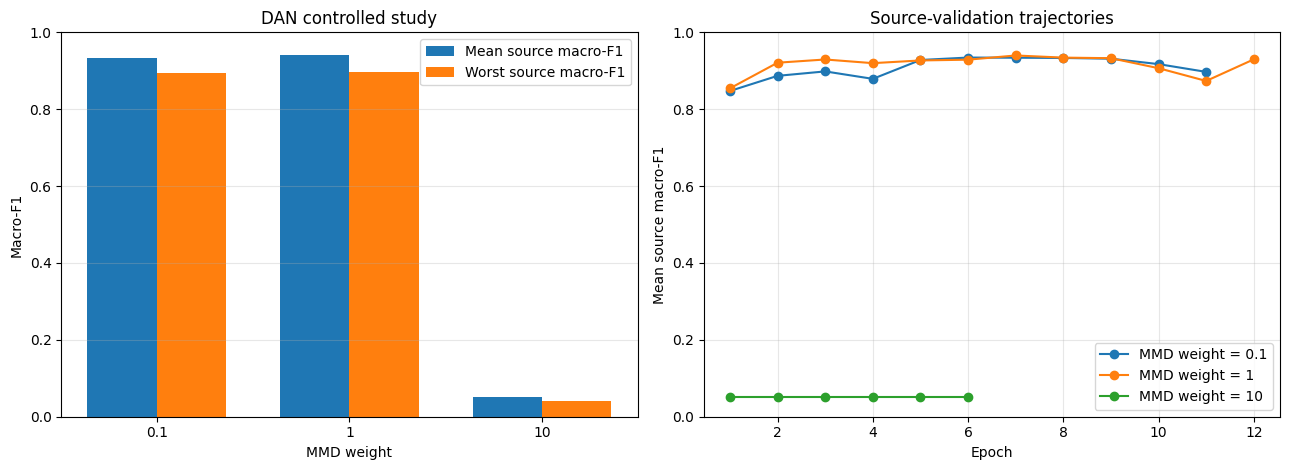

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/dan_controlled_study.png


In [11]:
lambda_histories = {
    0.1: controlled_results[
        0.1
    ]["history"],
    1.0: lambda_one_history,
    10.0: controlled_results[
        10.0
    ]["history"],
}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
)

x_positions = range(
    len(controlled_summary)
)

bar_width = 0.36

axes[0].bar(
    [
        position - bar_width / 2
        for position in x_positions
    ],
    controlled_summary[
        "mean_source_macro_f1"
    ],
    width=bar_width,
    label="Mean source macro-F1",
)

axes[0].bar(
    [
        position + bar_width / 2
        for position in x_positions
    ],
    controlled_summary[
        "worst_source_macro_f1"
    ],
    width=bar_width,
    label="Worst source macro-F1",
)

axes[0].set_xticks(
    list(x_positions)
)

axes[0].set_xticklabels(
    [
        "0.1",
        "1",
        "10",
    ]
)

axes[0].set_xlabel(
    "MMD weight"
)

axes[0].set_ylabel(
    "Macro-F1"
)

axes[0].set_ylim(
    0.0,
    1.0,
)

axes[0].set_title(
    "DAN controlled study"
)

axes[0].grid(
    axis="y",
    alpha=0.3,
)

axes[0].legend()

for mmd_weight, history in (
    lambda_histories.items()
):
    axes[1].plot(
        history["epoch"],
        history[
            "mean_source_validation_macro_f1"
        ],
        marker="o",
        label=(
            f"MMD weight = {mmd_weight:g}"
        ),
    )

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel(
    "Mean source macro-F1"
)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title(
    "Source-validation trajectories"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "dan_controlled_study.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [12]:
best_row = controlled_summary.loc[
    controlled_summary[
        "mean_source_macro_f1"
    ].idxmax()
]

controlled_metadata = {
    "study": "dan_mmd_weight",
    "seed": SEED,
    "tested_values": [
        0.1,
        1.0,
        10.0,
    ],
    "selection_data": (
        "source_validation_only"
    ),
    "target_labels_used": False,
    "fixed_bandwidth_multipliers": (
        list(BANDWIDTH_MULTIPLIERS)
    ),
    "gradient_clip_norm": 1.0,
    "selected_mmd_weight": float(
        best_row["mmd_weight"]
    ),
    "selected_mean_source_macro_f1": (
        float(
            best_row[
                "mean_source_macro_f1"
            ]
        )
    ),
    "results": (
        controlled_summary.to_dict(
            orient="records"
        )
    ),
}

metadata_path = (
    TASK2_REPO_ROOT
    / "results/"
    "dan_controlled_study_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        controlled_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        controlled_metadata,
        indent=2,
    )
)

{
  "study": "dan_mmd_weight",
  "seed": 6304,
  "tested_values": [
    0.1,
    1.0,
    10.0
  ],
  "selection_data": "source_validation_only",
  "target_labels_used": false,
  "fixed_bandwidth_multipliers": [
    0.5,
    1.0,
    2.0
  ],
  "gradient_clip_norm": 1.0,
  "selected_mmd_weight": 1.0,
  "selected_mean_source_macro_f1": 0.9397854027405872,
  "results": [
    {
      "mmd_weight": 0.1,
      "selected_epoch": 6,
      "mean_source_accuracy": 0.933534096713744,
      "mean_source_macro_f1": 0.9343684527757028,
      "worst_source_accuracy": 0.8902439024390244,
      "worst_source_macro_f1": 0.8950638985961621
    },
    {
      "mmd_weight": 1.0,
      "selected_epoch": 7,
      "mean_source_accuracy": 0.9390010451819851,
      "mean_source_macro_f1": 0.9397854027405872,
      "worst_source_accuracy": 0.8951219512195122,
      "worst_source_macro_f1": 0.8963366123967311
    },
    {
      "mmd_weight": 10.0,
      "selected_epoch": 1,
      "mean_source_accuracy": 0.216568